In [1]:
# Import libraries
import numpy as np
from scipy.ndimage import label
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
# Create a synthetic data
X, y = make_classification(n_samples = 1000, n_features = 10, n_informative=5, n_redundant=2, random_state=42)

In [3]:
# Split into train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [4]:
# Train a classifier
lor = LogisticRegression()
lor.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
# Get prediction probabilities
y_scores = lor.predict_proba(X_test)[:, 1]  # Probability of positive class
y_scores

array([0.06620052, 0.76149597, 0.15742498, 0.04375975, 0.39119547,
       0.24101252, 0.11865079, 0.64502973, 0.78670023, 0.71006605,
       0.86777489, 0.63567083, 0.49417747, 0.65138865, 0.34411521,
       0.61096906, 0.97985195, 0.50335357, 0.21141957, 0.05667935,
       0.05793209, 0.03208187, 0.20927969, 0.43192795, 0.00525026,
       0.78880249, 0.51726123, 0.14637635, 0.1857503 , 0.34635426,
       0.05668971, 0.01069917, 0.47929507, 0.98225   , 0.15031178,
       0.10736219, 0.81739368, 0.38972932, 0.32825671, 0.81782022,
       0.80192411, 0.87407077, 0.10594812, 0.25810127, 0.4336936 ,
       0.21375853, 0.96158692, 0.28645253, 0.03635626, 0.30802493,
       0.08110907, 0.00787957, 0.4738661 , 0.05227593, 0.4826429 ,
       0.14260543, 0.95996562, 0.13817129, 0.26683636, 0.97151293,
       0.39397836, 0.00862494, 0.13175106, 0.18885986, 0.81989141,
       0.27324438, 0.78329815, 0.62380913, 0.64912706, 0.67247485,
       0.945512  , 0.88495201, 0.49597816, 0.72116684, 0.42575

In [6]:
# Compute ROC curve values
# fpr --> False positive rate for different thresholds
# tpr --> True positive rate
# Thresholds --> probability cutoffs

# This function calculates FPR and TPR for each threshold from 0 to 1
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

In [7]:
roc_auc = roc_auc_score(y_test, y_scores)
roc_auc

0.9127741130326261

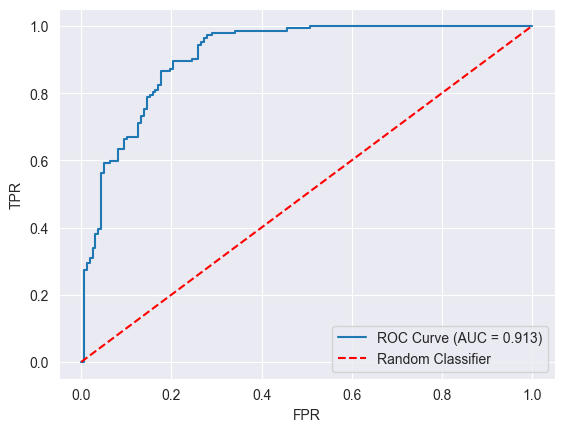

In [8]:
# Plot ROC curve
plt.plot(fpr, tpr, label = f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle = "--", color = "red", label="Random Classifier")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()